# Half-year adjoint vs the 5-yr reference, at matched lead times

**Runs** (both `baseline/from180yrPk_visc2x`, Tapenade-native hook builds, same `nIter0=3162240`, dT=1800 s, `adjDumpFreq`=5 d):

| Role | Run | Duration | Build |
| --- | --- | --- | --- |
| half-year adjoint | `DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028` | 180 d (8640 steps) | Tapenade-native hooks (`tapenade-active-dump-hook` branch) |
| reference | `DINO_1deg_tapAdj_ckpAll_5yr_from180yrPk_visc2x_run31039` | 1830 d (87840 steps) | 2026-09-01 hook-build rerun of 30995 (fc/adxx bitwise identical; seam-clean dumps) |

**Design.** Both adjoints start from the same 180-yr pickup, so their forward
trajectories coincide over the first 180 d. Their costs differ: J is the
terminal-30-day mean Atlantic heat transport ending at model year 180.49 (31028)
vs 185.0 (31039). Dumps land on absolute 5-day boundaries in both runs, so
records pair up **exactly at matched lead times** τ = 5, 10, …, 180 d before
each run's own cost window. A 180-d duration was chosen over 183 d precisely
for this alignment (183 is not a multiple of the 5-d dump cadence).

**What a difference means.** At matched lead τ the two runs evaluate the same
kind of sensitivity, but around background states 4.5 years apart — which is a
**half-cycle seasonal phase shift** (4.5 yr = 4 whole years + 0.5), so the two
cost windows sit in opposite seasons. Agreement at short leads measures how
robust the near-cost adjoint structure is to that; divergence with lead mixes
seasonal background differences with genuine lead-dependence.

**Seam mask.** The comparisons exclude ~2 cells around each MPI tile seam
(`i=17|18`, `34|35`, every `j` multiple of 22) and the channel's zonal periodic
seam. The mask dates from when the reference was pre-fix run 30995, whose
dumps kept partial halo sums there; since the 2026-09-01 rerun (31039) both
runs' dumps are seam-clean, and the mask is **retained only so the metrics
stay directly comparable** with the earlier execution of this notebook.


In [1]:
from pathlib import Path
import os
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML

import warnings; warnings.filterwarnings("ignore")
mpl.rcParams['animation.embed_limit'] = 50  # MB

In [2]:
run_dir = (
    "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/"
    "DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028/"
)
ref_dir = (
    "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/"
    "DINO_1deg_tapAdj_ckpAll_5yr_from180yrPk_visc2x_run31039/"
)

fig_dir = os.path.join(run_dir, "figures")
ani_dir = os.path.join(run_dir, "animations")
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(ani_dir, exist_ok=True)

nIter0   = 3162240
end_new  = nIter0 + 180*48        # 3170880
end_ref  = nIter0 + 1830*48       # 3250080
dump_stride = 240                 # 5 d

# matched leads: 5..180 d in 5-d steps, longest lead first (time-ascending order
# of the new run's records)
leads = np.arange(180, 0, -5)                      # days
iters_new = end_new - leads*48
iters_ref = end_ref - leads*48
len(leads), leads[:3], leads[-3:]

(36, array([180, 175, 170]), array([15, 10,  5]))

In [3]:
adj_vars = {
    'ADJtheta':  {'dims': ['k','j','i'],  'attrs': {'standard_name':'ADJtheta','long_name':'Adjoint Sensitivity to Potential Temperature','units':'dJ/degC'}},
    'ADJsalt':   {'dims': ['k','j','i'],  'attrs': {'standard_name':'ADJsalt','long_name':'Adjoint Sensitivity to Salinity','units':'dJ/(g/kg)'}},
    'ADJdiffkr': {'dims': ['k','j','i'],  'attrs': {'standard_name':'ADJdiffkr','long_name':'Adjoint Sensitivity to Vertical Diffusivity','units':'dJ/(m^2/s)'}},
    'ADJtaux':   {'dims': ['j','i_g'],    'attrs': {'standard_name':'ADJtaux','long_name':'Adjoint Sensitivity to Zonal Surface Wind Stress','units':'dJ/(N/m^2)'}},
    'ADJtauy':   {'dims': ['j_g','i'],    'attrs': {'standard_name':'ADJtauy','long_name':'Adjoint Sensitivity to Meridional Surface Wind Stress','units':'dJ/(N/m^2)'}},
    'ADJqnet':   {'dims': ['j','i'],      'attrs': {'standard_name':'ADJqnet','long_name':'Adjoint Sensitivity to Net Surface Heat Flux','units':'dJ/(W/m^2)'}},
    'ADJqsw':    {'dims': ['j','i'],      'attrs': {'standard_name':'ADJqsw','long_name':'Adjoint Sensitivity to Shortwave Flux','units':'dJ/(W/m^2)'}},
    'ADJempmr':  {'dims': ['j','i'],      'attrs': {'standard_name':'ADJempmr','long_name':'Adjoint Sensitivity to Freshwater Flux','units':'dJ/(m/s)'}},
}
adj_prefix = list(adj_vars)

ds_new = xmitgcm.open_mdsdataset(
    run_dir, grid_dir=run_dir, prefix=adj_prefix, iters=list(iters_new),
    ref_date=np.datetime64("2000-01-01T00:00:00"), delta_t=1800,
    extra_variables=adj_vars)

ds_ref = xmitgcm.open_mdsdataset(
    ref_dir, grid_dir=ref_dir, prefix=adj_prefix, iters=list(iters_ref),
    ref_date=np.datetime64("2000-01-01T00:00:00"), delta_t=1800,
    extra_variables=adj_vars)

# index both by lead time
ds_new = ds_new.assign_coords(lead=('time', leads)).swap_dims(time='lead')
ds_ref = ds_ref.assign_coords(lead=('time', leads)).swap_dims(time='lead')
ds_new.ADJtheta.shape, ds_ref.ADJtheta.shape

((36, 36, 198, 51), (36, 36, 198, 51))

## Cost function values

Not comparable as a regression (different cost windows), but both should be the
same order — J is per-tile-normalised terminal-30-d mean heat transport.

In [4]:
for name, d in [("31028 (180 d)", run_dir), ("31039 (5 yr ref)", ref_dir)]:
    with open(os.path.join(d, "costfunction.0000")) as f:
        print(f"{name:18s}: {f.readline().strip()}")

31028 (180 d)     : fc =  3.18174368541211E-01
31039 (5 yr ref)  : fc =  3.30992121938681E-01


## Seam mask

Excludes ~2 cells around each MPI tile seam and the zonal periodic seam.
Retained for continuity with the earlier execution (see header) — both runs'
dumps are seam-clean since the 2026-09-01 rerun.

In [5]:
def seam_mask(nj=198, ni=51):
    ok = np.ones((nj, ni), dtype=bool)
    # internal tile seams in i: between i=17|18 and 34|35 (1-based) -> +-2 cells
    for b in (17, 34):
        ok[:, b-2:b+2] = False                    # 0-based cols b-2..b+1
    # internal tile seams in j: every multiple of 22 -> +-2 cells
    for b in range(22, 198, 22):
        ok[b-2:b+2, :] = False
    # zonal periodic seam of the re-entrant channel: i in {1,2,50,51}, j ~ 13-44
    ok[12:44, 0:2]  = False
    ok[12:44, -2:] = False
    return ok

OK2D = seam_mask()
print(f"seam mask keeps {OK2D.mean()*100:.1f}% of the 51x198 horizontal grid")

seam mask keeps 69.7% of the 51x198 horizontal grid


## Matched-lead agreement metrics

Area-weighted Pearson correlation and RMS amplitude ratio
(`rms(31028)/rms(31039)`) over ocean cells outside the seam mask. 3-D fields
are evaluated at one depth level (chosen below); surface fields on their own
grid.

In [6]:
ZLEV = 14
zdepth = float(ds_new.Z.values[ZLEV])
print(f"3-D fields evaluated at Z index {ZLEV} = {zdepth:.0f} m")

def field_pair(var, lead):
    a = ds_new[var].sel(lead=lead)
    b = ds_ref[var].sel(lead=lead)
    if 'Z' in a.dims:
        a, b = a.isel(Z=ZLEV), b.isel(Z=ZLEV)
        hfac = ds_new.hFacC.isel(Z=ZLEV)
    else:
        hfac = ds_new.hFacC.isel(Z=0)
    w = (ds_new.rA * hfac).values
    A, B = np.asarray(a.values, float), np.asarray(b.values, float)
    m = (w > 0) & OK2D & np.isfinite(A) & np.isfinite(B)
    return A[m], B[m], w[m]

def metrics(var, lead):
    A, B, w = field_pair(var, lead)
    wm = lambda x: np.sum(w*x)/np.sum(w)
    Ac, Bc = A - wm(A), B - wm(B)
    denom = np.sqrt(wm(Ac**2)*wm(Bc**2))
    corr = wm(Ac*Bc)/denom if denom > 0 else np.nan
    rB = np.sqrt(wm(B**2))
    ratio = np.sqrt(wm(A**2))/rB if rB > 0 else np.nan
    return corr, ratio

METRIC_VARS = ['ADJtheta', 'ADJsalt', 'ADJtaux', 'ADJqnet']
corr = {v: np.array([metrics(v, L)[0] for L in leads]) for v in METRIC_VARS}
ratio = {v: np.array([metrics(v, L)[1] for L in leads]) for v in METRIC_VARS}

for v in METRIC_VARS:
    print(f"{v:9s} corr @5d={corr[v][-1]:+.3f}  @30d={corr[v][leads.tolist().index(30)]:+.3f}  "
          f"@90d={corr[v][leads.tolist().index(90)]:+.3f}  @180d={corr[v][0]:+.3f}")

3-D fields evaluated at Z index 14 = -231 m


ADJtheta  corr @5d=+0.981  @30d=+0.989  @90d=+0.775  @180d=+0.813
ADJsalt   corr @5d=+0.990  @30d=+0.989  @90d=+0.773  @180d=+0.777
ADJtaux   corr @5d=+1.000  @30d=+0.999  @90d=+0.876  @180d=+0.880
ADJqnet   corr @5d=+0.999  @30d=+0.996  @90d=+0.055  @180d=+0.503


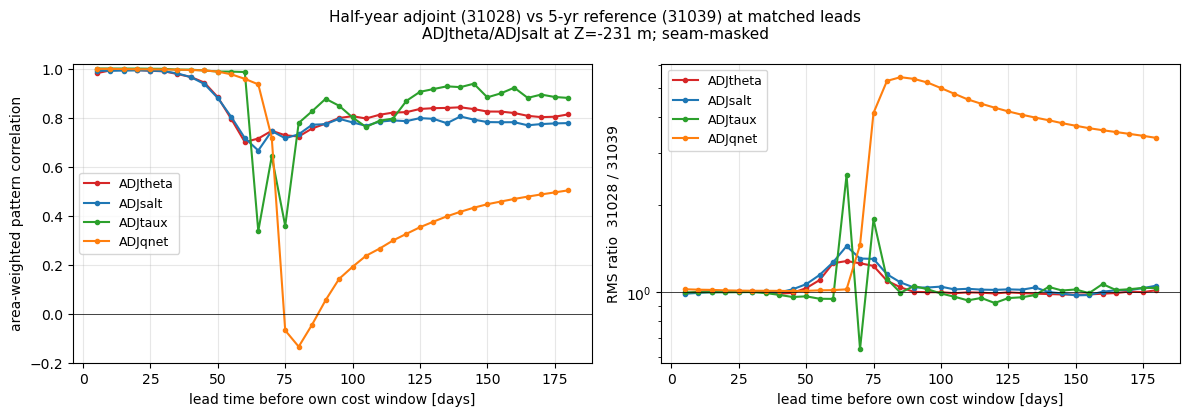

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
colors = {'ADJtheta':'C3','ADJsalt':'C0','ADJtaux':'C2','ADJqnet':'C1'}
for v in METRIC_VARS:
    axes[0].plot(leads, corr[v],  '-o', ms=3, color=colors[v], label=v)
    axes[1].plot(leads, ratio[v], '-o', ms=3, color=colors[v], label=v)
axes[0].set_ylabel('area-weighted pattern correlation')
axes[0].axhline(0, color='k', lw=.5); axes[0].set_ylim(-0.2, 1.02)
axes[1].set_ylabel('RMS ratio  31028 / 31039')
axes[1].axhline(1, color='k', lw=.5); axes[1].set_yscale('log')
for ax in axes:
    ax.set_xlabel('lead time before own cost window [days]')
    ax.invert_xaxis(); ax.grid(alpha=.3); ax.legend(fontsize=9)
lab = f"ADJtheta/ADJsalt at Z={zdepth:.0f} m; seam-masked"
fig.suptitle(f'Half-year adjoint (31028) vs 5-yr reference (31039) at matched leads\n{lab}', fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, 'matched_lead_metrics_vs_ref31039.png'), dpi=150, bbox_inches='tight')
plt.show()

## Matched-lead maps — ADJtheta

Rows: leads 15, 60, 120, 180 d. Columns: 31028, 31039, difference. One robust
symmetric scale per row (p98 of the reference field); the difference panel uses
the same scale so its amplitude reads directly against the fields.

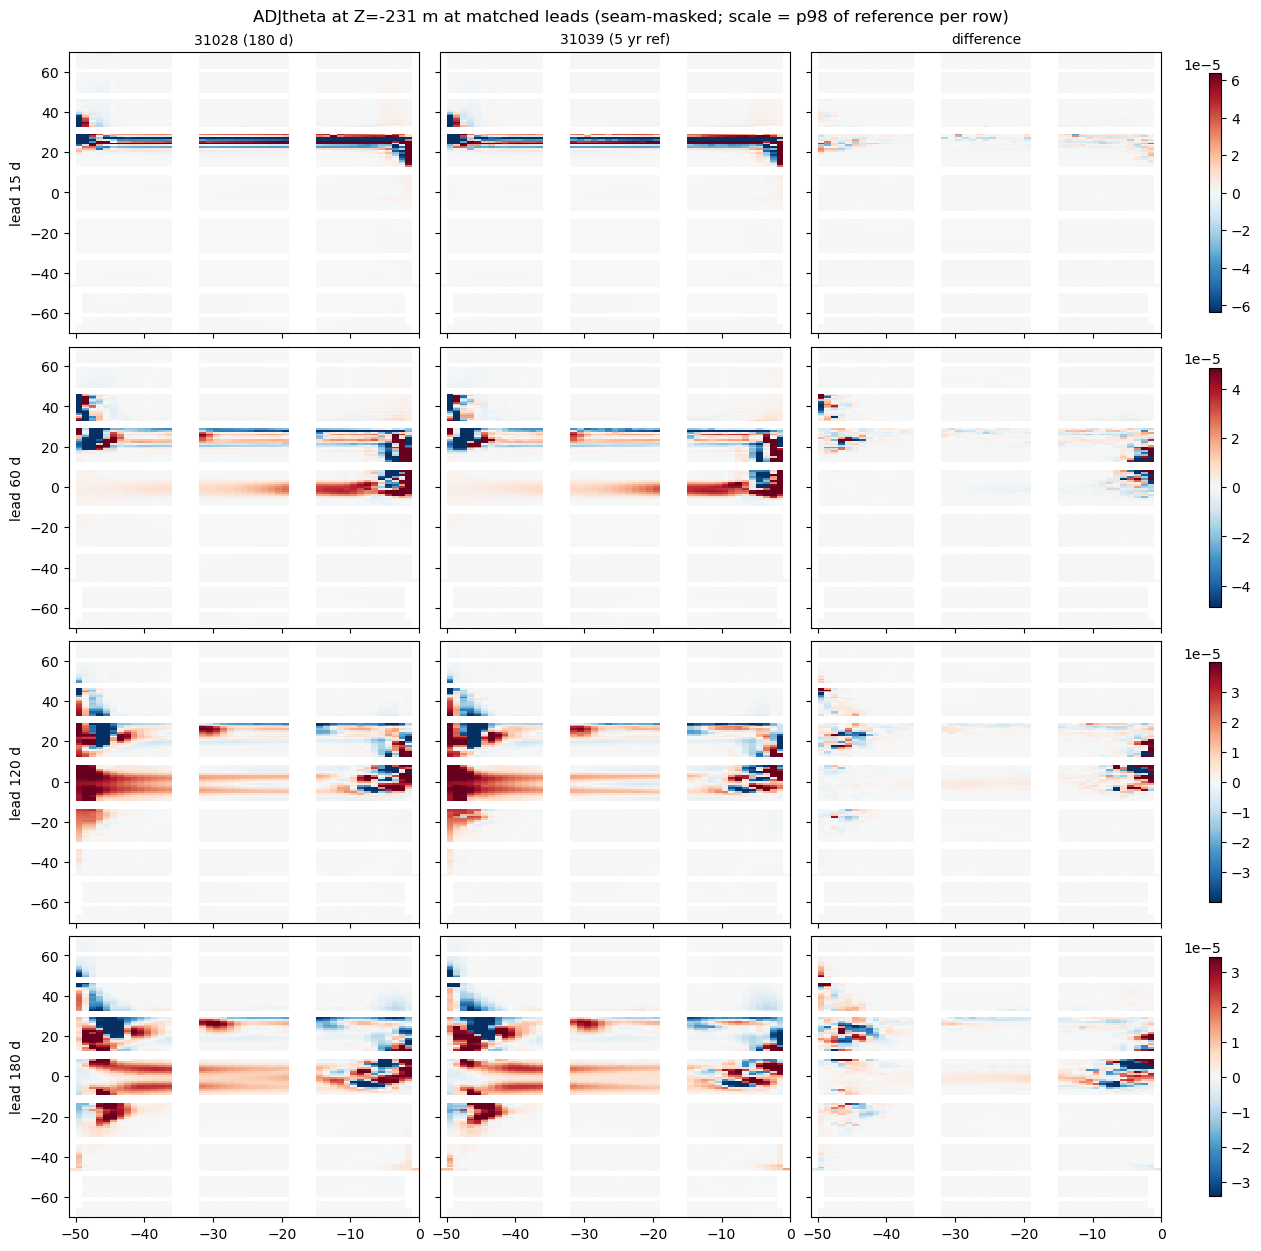

In [8]:
def masked_lvl(ds, var, lead, zlev=None):
    # NB: mask is applied with the field's OWN dims — ADJtaux/ADJtauy live on
    # staggered grids (YCxXG / YGxXC) and an hFacC-dimensioned mask would
    # silently broadcast to 3-D. hFacC is an approximation of the staggered
    # land mask there, adequate at this resolution.
    da = ds[var].sel(lead=lead)
    if 'Z' in da.dims:
        da = da.isel(Z=zlev)
        hfac = ds.hFacC.isel(Z=zlev)
    else:
        hfac = ds.hFacC.isel(Z=0)
    mvals = (hfac.values > 0) & OK2D
    return da.where(xr.DataArray(mvals, dims=da.dims))

def panel_rows(var, show_leads, zlev=ZLEV, p=98, fname=None):
    n = len(show_leads)
    fig, axes = plt.subplots(n, 3, figsize=(12.5, 3.1*n),
                             sharex=True, sharey=True, constrained_layout=True)
    for r, L in enumerate(show_leads):
        a = masked_lvl(ds_new, var, L, zlev)
        b = masked_lvl(ds_ref, var, L, zlev)
        d = a - b
        arr = b.values[np.isfinite(b.values)]
        v = np.percentile(np.abs(arr), p) if arr.size else 1.0
        for c, (da, ttl) in enumerate([(a, '31028 (180 d)'), (b, '31039 (5 yr ref)'), (d, 'difference')]):
            ax = axes[r, c]
            pcm = ax.pcolormesh(da['XC' if 'XC' in da.dims else 'XG'],
                                da['YC' if 'YC' in da.dims else 'YG'],
                                da.values, cmap='RdBu_r', vmin=-v, vmax=v)
            if r == 0: ax.set_title(ttl, fontsize=10)
            if c == 0: ax.set_ylabel(f'lead {L} d', fontsize=10)
            if c == 2: fig.colorbar(pcm, ax=ax, shrink=.85)
    zl = f' at Z={float(ds_new.Z.values[zlev]):.0f} m' if 'Z' in ds_new[var].dims else ''
    fig.suptitle(f'{var}{zl} at matched leads (seam-masked; scale = p{p} of reference per row)', fontsize=12)
    if fname:
        fig.savefig(os.path.join(fig_dir, fname), dpi=150, bbox_inches='tight')
    plt.show()

panel_rows('ADJtheta', [15, 60, 120, 180], fname='ADJtheta_z14_matched_leads_vs_ref.png')

## Matched-lead maps — ADJtaux and ADJqnet (surface forcing sensitivities)

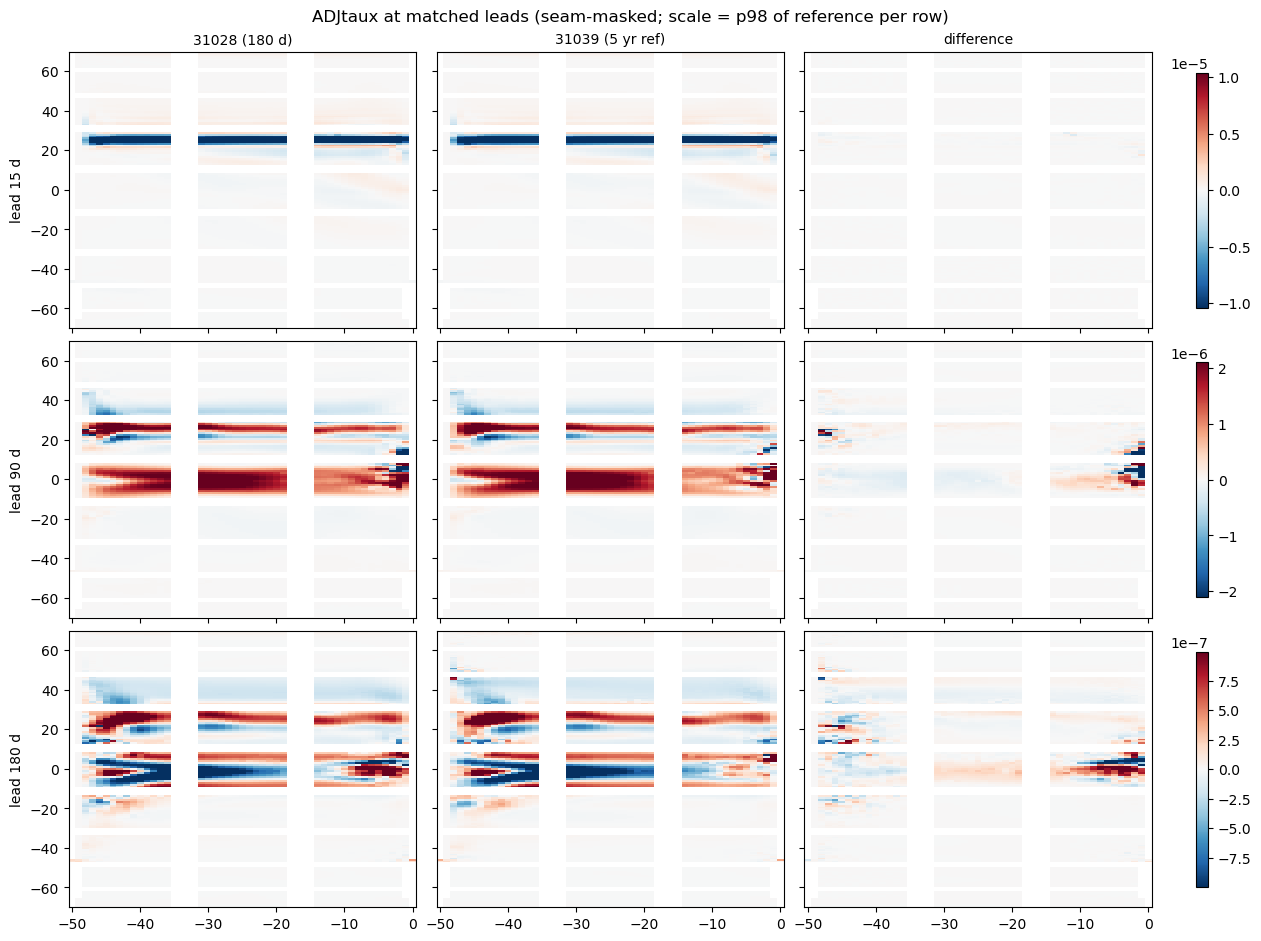

In [9]:
panel_rows('ADJtaux', [15, 90, 180], fname='ADJtaux_matched_leads_vs_ref.png')

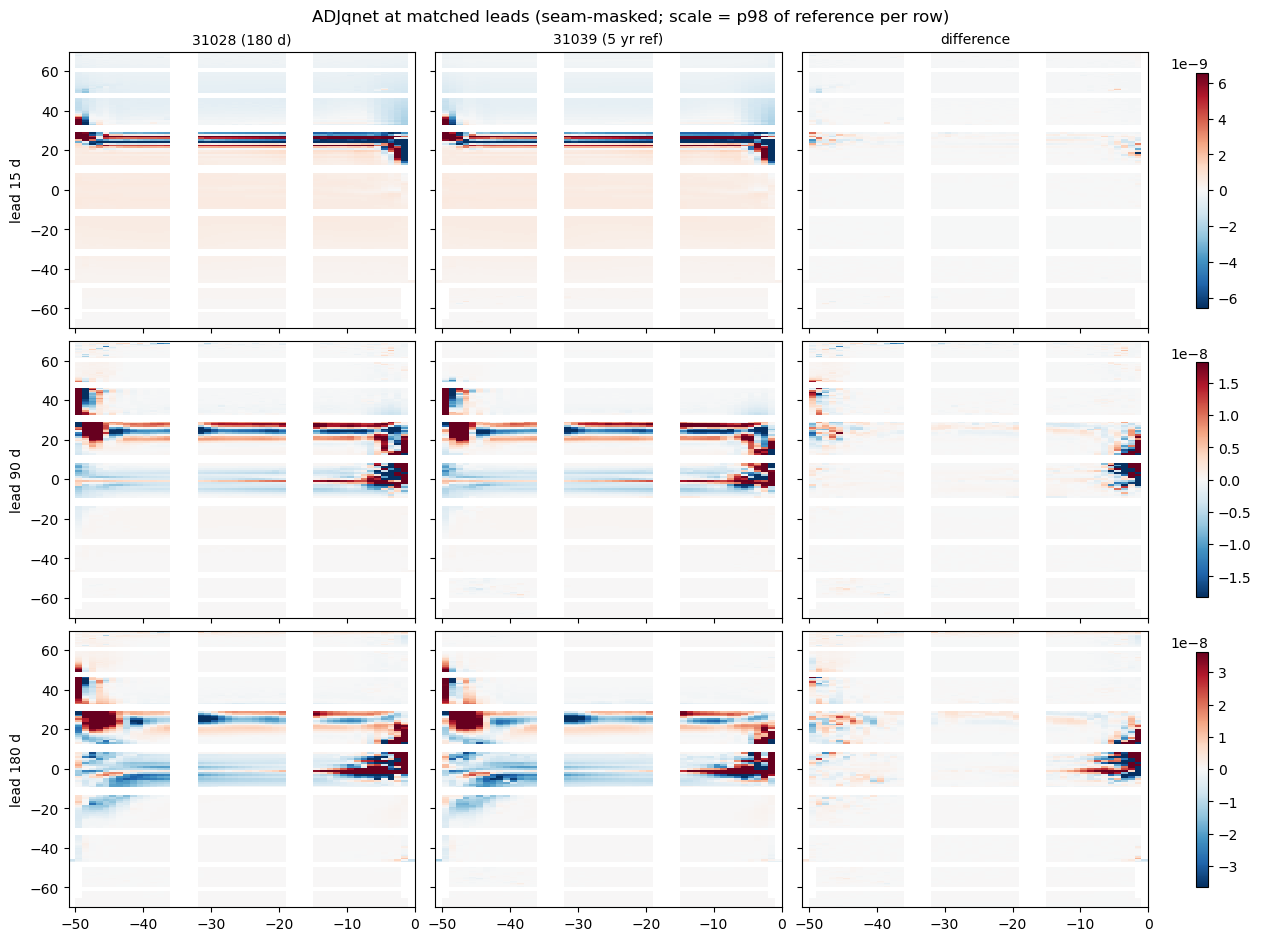

In [10]:
panel_rows('ADJqnet', [15, 90, 180], fname='ADJqnet_matched_leads_vs_ref.png')

## Side-by-side animation — ADJtheta at Z index 14

36 frames, lead 5 d → 180 d (adjoint computation order — the order the reverse
sweep computed them — the adjoint plume spreading back from the cost section). GIF saved under the run's `animations/`; inline
preview below.

In [11]:
def side_by_side_animation(var, zlev=ZLEV, p=98, interval_ms=350, fname=None):
    frames = leads[::-1]  # adjoint computation order: lead ascending 5 -> 180 d
    b_all = np.stack([masked_lvl(ds_ref, var, L, zlev).values for L in frames])
    a_all = np.stack([masked_lvl(ds_new, var, L, zlev).values for L in frames])
    arr = b_all[np.isfinite(b_all)]
    v = np.percentile(np.abs(arr), p) if arr.size else 1.0

    da0 = masked_lvl(ds_new, var, frames[0], zlev)
    X = da0['XC' if 'XC' in da0.dims else 'XG'].values
    Y = da0['YC' if 'YC' in da0.dims else 'YG'].values

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True, constrained_layout=True)
    ims = []
    for ax, ttl in zip(axes, ['31028 (180 d)', '31039 (5 yr ref)', 'difference']):
        im = ax.pcolormesh(X, Y, a_all[0], cmap='RdBu_r', vmin=-v, vmax=v)
        ax.set_title(ttl, fontsize=10); ims.append(im)
    fig.colorbar(ims[2], ax=axes[2], shrink=.8)
    zl = f' at Z={float(ds_new.Z.values[zlev]):.0f} m' if 'Z' in ds_new[var].dims else ''
    sup = fig.suptitle('', fontsize=12)

    def update(i):
        ims[0].set_array(a_all[i].ravel())
        ims[1].set_array(b_all[i].ravel())
        ims[2].set_array((a_all[i]-b_all[i]).ravel())
        sup.set_text(f'{var}{zl} — matched lead {frames[i]} d before own cost window')
        return ims

    ani = FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=False)
    if fname:
        ani.save(os.path.join(ani_dir, fname), writer=PillowWriter(fps=3), dpi=90)
        print("saved", os.path.join(ani_dir, fname))
    html = HTML(ani.to_jshtml())
    plt.close(fig)
    return html

side_by_side_animation('ADJtheta', fname='ADJtheta_z14_31028_vs_ref31039.gif')

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028/animations/ADJtheta_z14_31028_vs_ref31039.gif


<IPython.core.display.HTML object>
[text/html animation output (2.5 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [12]:
side_by_side_animation('ADJtaux', fname='ADJtaux_31028_vs_ref31039.gif')

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028/animations/ADJtaux_31028_vs_ref31039.gif


<IPython.core.display.HTML object>
[text/html animation output (2.5 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

## Solo animations of the half-year run (31028)

The run's own `ADJ*` evolution at full dump cadence, without the reference.

In [13]:
def solo_animation(var, zlev=ZLEV, p=98, interval_ms=350, fname=None):
    frames = leads[::-1]  # adjoint computation order: lead ascending 5 -> 180 d
    a_all = np.stack([masked_lvl(ds_new, var, L, zlev).values for L in frames])
    arr = a_all[np.isfinite(a_all)]
    v = np.percentile(np.abs(arr), p) if arr.size else 1.0
    da0 = masked_lvl(ds_new, var, frames[0], zlev)
    X = da0['XC' if 'XC' in da0.dims else 'XG'].values
    Y = da0['YC' if 'YC' in da0.dims else 'YG'].values
    fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)
    im = ax.pcolormesh(X, Y, a_all[0], cmap='RdBu_r', vmin=-v, vmax=v)
    fig.colorbar(im, ax=ax, shrink=.85)
    zl = f' at Z={float(ds_new.Z.values[zlev]):.0f} m' if 'Z' in ds_new[var].dims else ''
    ttl = ax.set_title('')
    def update(i):
        im.set_array(a_all[i].ravel())
        ttl.set_text(f'{var}{zl} — run 31028, lead {frames[i]} d')
        return [im]
    ani = FuncAnimation(fig, update, frames=len(frames), interval=interval_ms, blit=False)
    if fname:
        ani.save(os.path.join(ani_dir, fname), writer=PillowWriter(fps=3), dpi=90)
        print("saved", os.path.join(ani_dir, fname))
    html = HTML(ani.to_jshtml())
    plt.close(fig)
    return html

solo_animation('ADJtheta', fname='ADJtheta_z14_31028.gif')

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028/animations/ADJtheta_z14_31028.gif


<IPython.core.display.HTML object>
[text/html animation output (1.3 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [14]:
solo_animation('ADJsalt', fname='ADJsalt_z14_31028.gif')

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028/animations/ADJsalt_z14_31028.gif


<IPython.core.display.HTML object>
[text/html animation output (1.6 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [15]:
solo_animation('ADJqnet', fname='ADJqnet_31028.gif')

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_1deg_tapAdj_ckpAll_180d_from180yrPk_visc2x_run31028/animations/ADJqnet_31028.gif


<IPython.core.display.HTML object>
[text/html animation output (1.4 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

## Notes for interpretation

- Agreement at matched leads is **not** a regression test: at lead τ the two
  adjoints wrap background states 4.5 yr apart, i.e. **opposite seasonal
  phases** of the terminal window. Perfect agreement is not expected; what
  short leads show is how much of the near-cost adjoint structure is set by the
  section geometry and mean state rather than the season.
- The difference panels carry this seasonal-background effect only: both
  runs' dumps are seam-clean since the 2026-09-01 rerun of the reference
  (the seam mask is retained purely for metric continuity).
- `fc` values differ because they are different cost windows evaluated on the
  same trajectory epoch (180.5 yr) vs a later one (185 yr); both remain
  per-MPI-tile normalised (`nPx=3, nPy=9`).